# `Classification multi-tâches`

On va expérimenter un problème de classification multi-tâches sur un jeu de données d'images, issu du travail suivant:
3D Object Representations for Fine-Grained Categorization.   
- Jonathan Krause, Michael Stark, Jia Deng, Li Fei-Fei
- 4th IEEE Workshop on 3D Representation and Recognition, 
- at ICCV 2013 (3dRR-13). Sydney, Australia. Dec. 8, 2013. 

In [1]:
%pip -q install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub #type: ignore

CAR_PATH = "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP5/"
DATASET_PATH = CAR_PATH + "cardataset"
# Download latest version
DATASET_PATH = kagglehub.dataset_download("hassiahk/stanford-cars-dataset-full")
print("Path to dataset files:", DATASET_PATH)

Path to dataset files: /Users/asriel/.cache/kagglehub/datasets/hassiahk/stanford-cars-dataset-full/versions/1


Récupération les données: 
 - https://www.irit.fr/~Philippe.Muller/sample_cars.zip (10% du jeu de test complet).  
 - le fichier de méta-données + le code pour charger les données sur moodle.   
 - mettre les données + meta-données dans un répertoire (par exemple Car_dataset).   

In [3]:
import sys, os
sys.path.append(os.path.abspath(CAR_PATH))  # adapter le chemin


En apprentissage automatique, une tâche est le type de problème que le modèle doit résoudre, c’est‑à‑dire la nature de la prédiction ou de l’inférence attendue.

Le choix de la tâche dépend du problème et des données disponibles (étiquettes, valeurs à prédire,..).
Dans notre cas c'est une `tâche de classification` affecter l'entrée à une catégorie parmi un ensemble (marque, le type de véhicule).

Nous avons à faire à un apprentissage multi‑tâches le même modèle apprend ces différentes tâches en parallèle à partir du dataset constitué d’images véhicules, avec un jeu de données multi‑étiquettes :
 - la tâche doit prédire le modèle du véhicule (classification multiclasse).
 - la tâche doit prédire la marque du véhicule (Maserati, Porshe, Lamborghini, Rolls-Royce..)
 - la tâche doit prédire l'époque du véhicule (vintage, moderne)

In [4]:
#%pip -q install numpy scipy matplotlib pillow tqdm jupyter 
#%pip -q install torch torchvision --index-url https://download.pytorch.org/whl/cpu

In [5]:
import scipy.io #type: ignore
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import datasets, transforms, models
import torchvision.models as models
from torchvision.transforms import ToTensor
from tqdm import tqdm
from glob import glob
from os.path import isfile, join
import os
from PIL import ImageFile
from PIL import Image
ImageFile.LOAD_TRUNCATED_IMAGES = True
from matplotlib import pyplot as plt

In [6]:
device = torch.device("mps" if  torch.backends.mps.is_available()  else "cpu")

In [7]:
# pour l'entrainement en torch, on a besoin d'un générateur d'instances, 
# qui sera utilisé par le générateur de batch
class CarDataset(Dataset):
    def __init__(self,car_path,transform,translation_dict):
        self.path = car_path
        self.folder = [x for x in os.listdir(car_path)]
        self.transform = transform
        self.translation_dict = translation_dict

    def __len__(self):
        return len(self.folder)

    def __getitem__(self,idx):
        img_loc = os.path.join(self.path, self.folder[idx])
        image = Image.open(img_loc).convert('RGB')
        single_img = self.transform(image)

        label1 = self.translation_dict[self.folder[idx]][0]
        label2 = self.translation_dict[self.folder[idx]][1]
        label3 = self.translation_dict[self.folder[idx]][2]

        sample = {'image':single_img, 'labels': {'brand':label1, 
                                                 'vehicle_type':label2, 
                                                 'epoch':label3}}
        return sample   

In [8]:
from cars import load_annotations, brand_dict, vehicle_types_dict
translation_dict = load_annotations(CAR_PATH+"cars_annos.mat")

In [9]:
print(f'len dataset :{len(translation_dict)}')
print(f'file :{list(translation_dict.items())[0][0]} item : {list(translation_dict.items())[0][1]}')
print(f'features : {list(translation_dict.items())[0][1][0]}')

len dataset :16185
file :000001.jpg item : (5, 2, 0)
features : 5


### `Dénombrement des distributions par classes pour chaque tâche`

Dans ce corpus, nous avons des images de voiture de :
- différents modèles, 
- différentes marques,
- différentes époques. 
Nous allons essayer de prédire chacune de ses caractéristiques à partir de l'image.

In [10]:
counts_brand = {}
counts_model = {}
counts_epoch = {}

for _, item in translation_dict.items(): 
    counts_brand[item[0]] = counts_brand.get(item[0], 0) + 1
    counts_model[item[1]] = counts_model.get(item[1], 0) + 1
    counts_epoch[item[2]] = counts_epoch.get(item[2], 0) + 1

print(f'Distribution des classes : {len(translation_dict.items())}')
print(f'Distribution des classes par modèle : {counts_brand}')
print(f'Distribution des classes par marque : {counts_model}')
print(f'Distribution des classes par epoque : {counts_epoch}')

Distribution des classes : 16185
Distribution des classes par modèle : {5: 9874, 0: 1169, 1: 1055, 2: 1799, 3: 1253, 4: 1035}
Distribution des classes par marque : {2: 2855, 4: 8448, 3: 832, 0: 1907, 1: 2143}
Distribution des classes par epoque : {0: 5172, 1: 11013}


### `Prétraitement des données / préparation des batchs`

In [11]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
])

cardata = CarDataset(CAR_PATH+"car_dataset", transform=data_transforms,translation_dict=translation_dict)
# on ne garde que seulement 20% du dataset pour le train, car il est gros
# pas la peine si vous avez pris l'échantillon faites 80%/20%/0

n = len(cardata)

train_len = int(n * 0.8)
val_len   = int(n * 0.2)
ignored   = n - train_len - val_len  # assure la somme exacte
print(n, train_len, val_len, ignored, train_len + val_len + ignored)

train_set, val_set, ignored_data = torch.utils.data.random_split(cardata, [train_len, val_len,ignored])

# DataLoader va générer les batchs
train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=0, drop_last=True)
test_loader = DataLoader(val_set, batch_size=16, shuffle=False, num_workers=0, drop_last=True)

16185 12948 3237 0 16185


torch.Size([3, 224, 224])


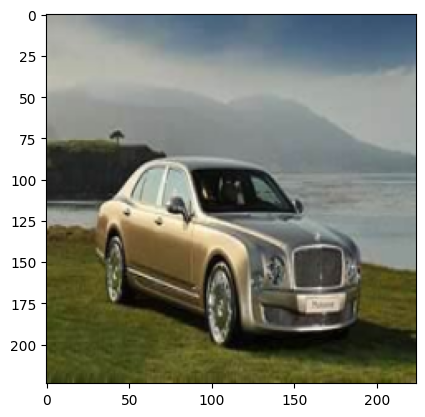

In [12]:
# pour montrer les images il faut remettre la dimension des canaux RGB en dernier
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img = cardata[0]['image'] * std + mean
print(cardata[0]['image'].shape)
plt.imshow(img.permute(1,2,0))
plt.show()

## `Extacteur de caratéristiques et apprentissage`
:::
Ce qui suit s’inscrit dans du fine‑tuning à partir d’un modèle pré‑entraîné (ResNet34 sur ImageNet), en remplaçant la tête de classification d’origine par des têtes adaptées à nos tâches (marque, type, époque).    
`resnet34(pretrained=True)`    
 - charge un réseau déjà entraîné sur ImageNet (1000 classes). 
 - sert d’extracteur de features générique  
​`children()[:-1]`   
Retire la dernière couche fully‑connected, dont on garde uniquement :
   - les convolutions, 
   - les batch norms / ReLU, 
   - les pooling,
   - le global average pooling.   
 - La sortie est un vecteur de 512 features par image
:::
:::
`Chaîne de traitement dans ResNet`.  
Pour une image [3, 224, 224] le ResNet34 applique successivement:
- ​Des couches convolutionnelles + ReLU + pooling. 
- Elles transforment l’image en un tenseur de plus en plus profond et plus petit spatialement. 
- Exple. [64, 112, 112], puis [128, 56, 56], …, jusqu’à [512, H, W].

`Global average pooling`.
- Remplace chaque carte [H, W] par sa moyenne obtenant une projection [512, 1, 1]
- Le flatten implicite passe d'un vecteur [512, 1, 1] à [512], 
- Il sert d’entrée à la couche fully‑connected finale (fc).
`Donc`
 - __Entrée du modèle :__ image [3, 224, 224].
 - __Sortie du backbone (sans fc) :__ features [512] par image (ou [B, 512] en batch).
 - __Entrée des couches linéaires (nn.Linear(512, n_classes)) :__ ce vecteur 512, pas l’image brute.
:::
:::
#### `A faire à compléter :` 
 - il faut un modèle spécialisant chaque tâche
 - essayez par exemple avec une couche linéaire simple
 - ou une couche linéaire après une couche de drop-out
 :::

In [13]:
class MultilabelClassifier(nn.Module):
    def __init__(self, n_brand, n_vehicle_type, n_epoch,dropout_rate=0.4):
        super().__init__()
        # la partie commune du modèle = resnet moins sa couche finale, dimension de sortie = 512
        # charge un ResNet34 pré‑entraîné sur ImageNet (1000 classes). 

        self.resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.in_features = self.resnet.fc
        # Retire la dernière couche fully‑connected finale d’ImageNet pour ne garder que 
        self.model_wo_fc = nn.Sequential(*(list(self.resnet.children())[:-1]))

        self.dropout = nn.Dropout(dropout_rate)
        # modèles spécialisés pour chacune des 3 caractéristiques
        self.brand = nn.Linear(512,n_brand)
        self.vehicle_type =  nn.Linear(512,n_vehicle_type)    
        self.epoch = nn.Linear(512,n_epoch)

        self.brand_dropout = nn.Sequential(self.dropout, self.brand)
        self.vehicule_dropout = nn.Sequential(self.dropout, self.vehicle_type)
        self.epoch_dropout = nn.Sequential(self.dropout, self.epoch)

    def forward(self, x):
        x = self.model_wo_fc(x)
        x = torch.flatten(x, 1)

        # Utilisation des modèles avec couche linéaire simple
        brand_output = self.brand_dropout(x)
        vehicleType_output = self.vehicule_dropout(x)
        epoch_output = self.epoch_dropout(x)

        return {
            'brand': brand_output,
            'vehicle_type': vehicleType_output,
            'epoch': epoch_output,
        }

In [14]:
model = MultilabelClassifier(6,5,2)
x = torch.randn(1, 3, 224, 224)

with torch.no_grad():
    model_wo_fc = nn.Sequential(*(list(model.resnet.children())[:-1]))
    x = torch.randn(1, 3, 224, 224)  # image factice
    feats = model.model_wo_fc(x)
    print(feats.shape)               # attendu: torch.Size([1, 512, 1, 1])

    flat = torch.flatten(feats, 1)
    print(flat.shape)

torch.Size([1, 512, 1, 1])
torch.Size([1, 512])


In [15]:
device = torch.device("mps" if  torch.backends.mps.is_available()  else "cpu")
print(device)
model = MultilabelClassifier(6,5,2).to(device)

mps


### `Définition d'une fonction de loss globale`   

In [16]:
def criterion(loss_func,outputs,pictures):
    losses = 0
    for i, key in enumerate(outputs):
        losses += loss_func(outputs[key], pictures['labels'][f'{key}'].to(device))
    return losses


### `Autre choix de pondération de la loss par type de labels`  

##### `Pondération de la loss % nombre de classes Brand`

In [17]:
import torch

num_classes_brand = len(counts_brand)
counts_list = [counts_brand[i] for i in range(num_classes_brand)]  # [1907, 2143, 2855, 832, 8448]
counts_tensor = torch.tensor(counts_list, dtype=torch.float32)

# poids ∝ 1 / count
weights_brand = 1.0 / counts_tensor
weights_brand = weights_brand / weights_brand.sum() * num_classes_brand  # normalisation optionnelle

##### `Pondération % nombre de classes pour la loss sur label vehicle type`

In [18]:
num_classes_model = len(counts_model)
# Construire la liste dans l'ordre des indices 0..5
counts_list = [counts_model[i] for i in range(num_classes_model)]
counts_tensor_model = torch.tensor(counts_list, dtype=torch.float32)

# Poids inverses des fréquences (avec normalisation optionnelle)
weights_model = 1.0 / counts_tensor_model
weights_model = weights_model / weights_model.sum() * num_classes_model


##### `Pondération % nombre de classes pour la loss sur label epoch`

In [19]:
num_classes_epoch = len(counts_epoch)
# Construire la liste dans l'ordre des indices 0..5
counts_list = [counts_epoch[i] for i in range(num_classes_epoch)]
counts_tensor_counts_epoch = torch.tensor(counts_list, dtype=torch.float32)

# Poids inverses des fréquences (avec normalisation optionnelle)
weights_epoch = 1.0 / counts_tensor_counts_epoch
weights_epoch = weights_epoch / weights_epoch.sum() * num_classes_epoch

### `Fonction d'apprentissage`

In [20]:
# extraire les IDs distincts
model_ids  = sorted({v[0] for v in translation_dict.values()})
brand_ids  = sorted({v[1] for v in translation_dict.values()})
epoch_ids  = sorted({v[2] for v in translation_dict.values()})

# créer des noms par défaut
brand_dict = {i: f"brand_{i}" for i in brand_ids}
vehicle_types_dict = {i: f"type_{i}" for i in model_ids}
epoch_dict = {i: f"epoch_{i}" for i in epoch_ids}

class_lists = [
    [brand_dict[i] for i in brand_ids],
    [vehicle_types_dict[i] for i in model_ids],
    [epoch_dict[i] for i in epoch_ids],
]
class_lists

[['brand_0', 'brand_1', 'brand_2', 'brand_3', 'brand_4'],
 ['type_0', 'type_1', 'type_2', 'type_3', 'type_4', 'type_5'],
 ['epoch_0', 'epoch_1']]

In [21]:
def training(model,device,lr_rate,epochs,train_loader):
    num_epochs = epochs
    losses = []
    checkpoint_losses = []

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_rate)
    n_total_steps = len(train_loader)

    #loss_func = nn.CrossEntropyLoss()

    ce_brand   = nn.CrossEntropyLoss(weight=weights_brand.to(device))
    ce_vehicle = nn.CrossEntropyLoss(weight=weights_model.to(device))
    ce_epoch   = nn.CrossEntropyLoss(weight=weights_epoch.to(device))

    for epoch in range(num_epochs):
        i = 0
        for batch in tqdm(train_loader,desc=f"epoch {epoch+1}"):
            images = batch['image'].to(device)
            y_brand = batch['labels']['brand'].to(device)
            y_vehicle = batch['labels']['vehicle_type'].to(device)
            y_epoch = batch['labels']['epoch'].to(device)

            outputs = model(images)

        #    if epoch == 0 and i == 0:
        #        print("brand logits:", outputs['brand'].device)
        #        print("y_brand:", y_brand.device)
        #        print("weights_brand:", ce_brand.weight.device) #type: ignore


            loss_brand   = ce_brand(outputs['brand'], y_brand)
            loss_vehicle = ce_vehicle(outputs['vehicle_type'], y_vehicle)
            loss_epoch   = ce_epoch(outputs['epoch'], y_epoch)

            #loss_brand = criterion(loss_brand,outputs, y_brand)
            #loss_vehicle = criterion(loss_vehicle,outputs, y_vehicle)
            #loss_epoch = criterion(loss_epoch,outputs, y_epoch)

            loss = loss_brand + loss_vehicle + loss_epoch  # ou pondéré    

            losses.append(loss.item()) # type: ignore

            optimizer.zero_grad()
            loss.backward()           # type: ignore
            optimizer.step()

            if (i+1) % (int(n_total_steps/1)) == 0:
                checkpoint_loss = torch.tensor(losses).mean().item()
                checkpoint_losses.append(checkpoint_loss)
                print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {checkpoint_loss:.4f}')
            i = i + 1
    return checkpoint_losses

#### `A faire, entrainer le modèle`

In [22]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

lr_rate = 0.001
epochs = 10

checkpoint_losses = training(model,device,lr_rate,epochs,train_loader)

epoch 1: 100%|██████████| 809/809 [01:52<00:00,  7.21it/s]


Epoch [1/10], Step [809/809], Loss: 4.2056


epoch 2: 100%|██████████| 809/809 [01:58<00:00,  6.84it/s]


Epoch [2/10], Step [809/809], Loss: 4.1411


epoch 3: 100%|██████████| 809/809 [02:04<00:00,  6.50it/s]


...

Epoch [8/10], Step [809/809], Loss: 3.7926


epoch 9: 100%|██████████| 809/809 [02:23<00:00,  5.64it/s]


Epoch [9/10], Step [809/809], Loss: 3.7028


epoch 10: 100%|██████████| 809/809 [02:06<00:00,  6.39it/s]

Epoch [10/10], Step [809/809], Loss: 3.6051


In [23]:
# Fonction de calcul des performances en validation
# Que veut dire l'accuracy par classe ici ? corriger l'affichage
def validation(model, device, dataloader, class_lists):
    all_predictions = torch.tensor([]).to(device)
    all_true_labels = torch.tensor([]).to(device)
    
    model.to(device)
    model.eval()

    n_tasks = len(class_lists)

    n_correct = [0 for _ in range(n_tasks)]
    n_samples = 0

    n_class_correct = []
    n_class_samples = []
    for cls in class_lists:
        n_class_correct.append([0 for i in range(len(cls))])
        n_class_samples.append([0 for i in range(len(cls))])
    
    with torch.no_grad():

            # l'eval se fait par batch aussi, et sur le gpu si possible
            for batch in tqdm(dataloader, desc="validation"):
                images = batch['image'].to(device)
                outputs = model(images)
                # mettre les labels dans une liste dans l'ordre des clés de class_lists
                labels_list = [
                    batch['labels']['brand'].to(device),
                    batch['labels']['vehicle_type'].to(device),
                    batch['labels']['epoch'].to(device),
                    ]

                batch_size = labels_list[0].size(0)
                n_samples += batch_size
                #labels = [pictures['labels'][picture].to(device) for picture in pictures['labels']]

                for task_idx, labels in enumerate(labels_list):
                    # clé associée à la tâche
                    key = ['brand', 'vehicle_type', 'epoch'][task_idx]
                    logits = outputs[key]              # [B, n_classes]
                    _, predicted = torch.max(logits, dim=1)

                    # global accuracy par tâche
                    n_correct[task_idx] += (predicted == labels).sum().item()

                    # per-class accuracy
                    for k in range(batch_size):
                        label = labels[k].item()
                        pred = predicted[k].item()
                        if 0 <= label < len(n_class_samples[task_idx]):
                            if label == pred:
                                n_class_correct[task_idx][label] += 1
                            n_class_samples[task_idx][label] += 1

    return n_correct, n_samples, n_class_correct, n_class_samples

In [24]:
def class_acc(n_correct,n_samples,n_class_correct,n_class_samples,class_list):
    for i in range(len(class_list)):
          print("-------------------------------------------------")
          acc = 100.0 * n_correct[i] / n_samples
          print(f'Overall class performance: {round(acc,1)} %')
          for k in range(len(class_list[i])):
              try:
                acc = 100.0 * n_class_correct[i][k] / n_class_samples[i][k]
              except: 
                   print(f'cette classe est nulle : {class_list[i][k]}')
              print(f'Accuracy of {class_list[i][k]}: {round(acc,1)} %')
    print("-------------------------------------------------")

In [25]:
from cars import load_annotations, brand_dict, vehicle_types_dict

class_lists=[]
classes_epoch = ['2009 and earlier','2010 and later']
class_lists.append(list(brand_dict.values()))
class_lists.append(list(vehicle_types_dict.values()))
class_lists.append(classes_epoch)

n_correct,n_samples,n_class_correct,n_class_samples = validation(model,device, test_loader,class_lists)

validation: 100%|██████████| 202/202 [00:29<00:00,  6.93it/s]


In [28]:
class_acc(n_correct,n_samples,n_class_correct,n_class_samples,class_lists)

-------------------------------------------------
Overall class performance: 53.4 %
Accuracy of Audi: 67.5 %
Accuracy of BMW: 81.9 %
Accuracy of Chevrolet: 36.0 %
Accuracy of Dodge: 49.2 %
Accuracy of Ford: 41.4 %
Accuracy of Other: 53.7 %
-------------------------------------------------
Overall class performance: 56.4 %
Accuracy of Convertible: 51.4 %
Accuracy of Coupe: 46.6 %
Accuracy of SUV: 86.3 %
Accuracy of Van: 69.3 %
Accuracy of Other: 48.5 %
-------------------------------------------------
Overall class performance: 70.0 %
Accuracy of 2009 and earlier: 63.3 %
Accuracy of 2010 and later: 73.3 %
-------------------------------------------------


$$ \text{Accuracy} =  \frac{TP + TN}{TP + TN +FP + FN} \text{ .  Précision} = \frac{TP}{TP + FP} \text{ .  Recall} = \frac{TP}{TP + FN}$$

In [29]:

for i, (correct, total) in enumerate(zip(n_class_correct, n_class_samples)):
   if i == 0 :
       print(f"\nPrécision sur le brand { n_correct[i]/(n_correct[i] +  sum(correct))}")  
       print(f"Recall sur le brand {n_correct[i]/(n_correct[i] +  (n_correct[i] - sum(correct)))}\n")  
   elif i == 1 :    
       print(f"\nPrécision sur le type de vehicle {n_correct[i]/(n_correct[i] + sum(correct))}") 
       print(f"Recall sur le type de vehicle {n_correct[i]/(n_correct[i] + (n_correct[i] - sum(correct)))}\n") 
   elif i == 2 :      
       print(f"\nPrécision sur l'époque {n_correct[i]/(n_correct[i] + sum(correct))}")
       print(f"Recall sur l'époque {n_correct[i]/(n_correct[i] +  (n_correct[i] - sum(correct)))}\n")          

   for j, (corec, tot)in enumerate(zip(correct,total)):
        if i == 0 :
            print(f' - {brand_dict[j]} correct : {corec} total : {tot}')
        elif i == 1 : 
            print(f' - {vehicle_types_dict[j]} correct : {corec} total : {tot}')
        elif i == 2 : 
            print(f' - {classes_epoch[j]} correct : {corec} total : {tot}') 
   


Précision sur le brand 0.5
Recall sur le brand 1.0

 - Audi correct : 158 total : 234
 - BMW correct : 177 total : 216
 - Chevrolet correct : 132 total : 367
 - Dodge correct : 125 total : 254
 - Ford correct : 87 total : 210
 - Other correct : 1048 total : 1951

Précision sur le type de vehicle 0.5
Recall sur le type de vehicle 1.0

 - Convertible correct : 200 total : 389
 - Coupe correct : 191 total : 410
 - SUV correct : 491 total : 569
 - Van correct : 122 total : 176
 - Other correct : 818 total : 1688

Précision sur l'époque 0.5
Recall sur l'époque 1.0

 - 2009 and earlier correct : 672 total : 1062
 - 2010 and later correct : 1590 total : 2170
